In [1]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import os
import cv2

In [2]:
IMG_WIDTH, IMG_HEIGHT = 240, 240
BATCH_SIZE = 32
EPOCHS = 25

In [3]:
data_path = "Data"

In [4]:
def load_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    return img

images = []
labels = []


label_map = {
    'ECG Images of Patient that have abnormal heartbeat': 0,
    'ECG Images of Patient that have History of MI': 1,
    'ECG Images of Myocardial Infarction Patients': 2,
    'Normal Person ECG Images': 3
}


for split in ['train', 'test']:
    split_path = os.path.join(data_path, split)
    if not os.path.exists(split_path):
        continue

    for folder in os.listdir(split_path):
        folder_path = os.path.join(split_path, folder)

        assigned_label = None
        for key, val in label_map.items():
            if folder.startswith(key):
                assigned_label = val
                break

        if assigned_label is not None and os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(folder_path, file)
                    img = load_image(file_path)
                    if img is not None:
                        images.append(img)
                        labels.append(assigned_label)

images = np.array(images)
labels = np.array(labels)

In [5]:
from keras.utils import to_categorical

labels = to_categorical(labels)

In [6]:
print(labels)

[[0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 ...
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


In [7]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(4, activation='softmax')
])

C:\Users\abdul\rafay-clusternew\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam',
              loss= tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

In [9]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 238, 238, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 119, 119, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 117, 117, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 58, 58, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 215296)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    27,558,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,577,924 (105.20 MB)

 Trainable params: 27,577,924 (105.20 MB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=19)

In [11]:
print(labels.shape)
print(images.shape)

(3951, 4)
(3951, 240, 240, 3)


In [12]:
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=19, stratify=labels
)

history = model.fit(
    train_images, train_labels,
    validation_data=(test_images, test_labels),
    batch_size=32,
    epochs=EPOCHS
)

Epoch 1/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6617 - loss: 1.4096 - val_accuracy: 0.9735 - val_loss: 0.1058
Epoch 2/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 99s 997ms/step - accuracy: 0.9801 - loss: 0.0754 - val_accuracy: 1.0000 - val_loss: 0.0218
Epoch 3/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 93s 939ms/step - accuracy: 0.9997 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 4.7053e-04
Epoch 4/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 95s 960ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 3.9806e-04
Epoch 5/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 92s 933ms/step - accuracy: 1.0000 - loss: 6.0268e-04 - val_accuracy: 1.0000 - val_loss: 8.8289e-05
Epoch 6/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 1.0000 - loss: 2.4114e-04 - val_accuracy: 1.0000 - val_loss: 1.6843e-04
Epoch 7/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 97s 981ms/step - accuracy: 0.9744 - loss: 0.0808 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 8/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 98s 994ms/step - accuracy: 1.0000 - los

In [13]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc:.2f}')

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.9912 - loss: 0.0175
Test accuracy: 0.99


In [14]:
model.save('model.h5')

In [15]:
import zipfile

with zipfile.ZipFile('model.h5.zip', 'w') as zip_file:
    zip_file.write('model.h5')

In [18]:


# 1. Load the saved model from disk
loaded_model = tf.keras.models.load_model('model.h5')
print("Model loaded successfully!")

# 2. Test prediction function on a single image
def predict_ecg(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (240, 240))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    img = np.expand_dims(img, axis=0)  # Shape becomes (1, 240, 240, 3)

    predictions = loaded_model.predict(img)
    class_idx = np.argmax(predictions)

    classes = ['Abnormal Heartbeat', 'History of MI', 'Myocardial Infarction', 'Normal']
    print(f"Predicted Class: {classes[class_idx]} ({predictions[0][class_idx]*100:.1f}% confidence)")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted Class: Normal (100.0% confidence)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


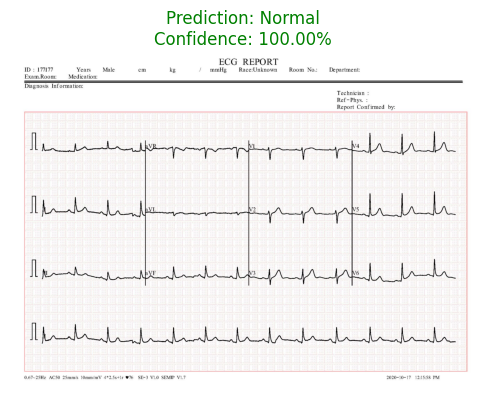

In [21]:
# this code i added by my self just checking the sample output

import matplotlib.pyplot as plt
def predict_and_display_ecg(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Failed to load image. Check the file path.")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(img_rgb, (240, 240)) / 255.0
    input_tensor = np.expand_dims(resized_img, axis=0)
    predictions = loaded_model.predict(input_tensor)
    class_idx = np.argmax(predictions)
    confidence = predictions[0][class_idx] * 100

    classes = ['Abnormal Heartbeat', 'History of MI', 'Myocardial Infarction', 'Normal']
    predicted_label = classes[class_idx]
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%", fontsize=12, color='green')
    plt.axis('off')
    plt.show()
predict_and_display_ecg(sample_image_path)
